In [ ]:
!pip install langgraph
!pip install langchain
!pip install langsmith
!pip install langchain_groq
!pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [3]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.3-70b-versatile", api_key=GROQ_API_KEY, streaming=True)

## Streaming

Let's create a simple graph

In [22]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import add_messages

class State(TypedDict):
  messages : Annotated[list, add_messages]

In [23]:
def Chatbot(state:State):
  return {"messages" : [model.invoke(state["messages"])]}

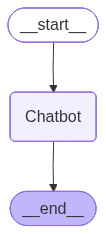

In [24]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END, START

builder = StateGraph(State)
builder.add_node("Chatbot", Chatbot)

builder.add_edge(START, "Chatbot")
builder.add_edge("Chatbot", END)

graph = builder.compile(checkpointer=MemorySaver())

graph

In [25]:
config = {
    "configurable" : {
        "thread_id" : "user1435"
    }
}

In [26]:
graph.invoke({"messages" : "Hi my name is Namit Kumar and i like programming"}, config=config)

{'messages': [HumanMessage(content='Hi my name is Namit Kumar and i like programming', additional_kwargs={}, response_metadata={}, id='e8b99576-115c-4963-8e5b-eb1f326b2eb2'),
  AIMessage(content='Nice to meet you, Namit Kumar! Programming can be a fascinating and rewarding field. What programming languages are you interested in or have experience with? Are you working on any projects or have a favorite area of focus, such as web development, mobile app development, or data science?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019f4c02-828d-72e1-9946-6e2ba409ba17', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 58, 'total_tokens': 104})]}

So now let's look at Streaming, it will be helpful when creating some chatbots

Methods :
- .stream() - Synchronous, Each iteration gives next streamed item
- astream() - Asynchronous, lets you receive graph outputs one by one while the graph is still running.

Now there are two parameters we can enter:
- values
- updates


Imagine This :

Initial state
<pre>
{
  "a" : 1
}
</pre>

Node 1
<pre>
{
  "a" : 1,
  "b" : 2
}
</pre>

Node 2
<pre>
{
  "a" : 1,
  "b" : 2,
  "c" : 3
}
</pre>


<b><u>Values (stream_mode = "values")</b></u>

Output:

<pre>
{
  a
}

  ↓

{
  a
  b
}

  ↓

{
  a
  b
  c
}
</pre>
Entine state everytime


<b><u>Updates (stream_mode = "updates")</b></u>

Output :

<pre>
{
  b
}

  ↓

{
  c
}
</pre>

Provides only what changes

Basically stream() and astream() used with both of these provide same result like "updates" and "values" are independent of these.

We need stream() and astream() because puthon supports two programing models:

1. Synchronous
2. Asynchronous

and Langgraph supports both

Like we are building a chatbot and we used Synchronous system then

<pre>
User 1
Wait...
Wait...
Wait...
Done

Now User 2

Wait...
Wait...
Done
</pre>
Everyone waits their turn.

But with Asynchronous mechanism

<pre>
User 1 waiting for LLM...

↓ switch

User 2 waiting for database...

↓ switch

User 3 waiting for tool...

↓ switch

User 1 receives token

↓ switch

User 2 receives result
</pre>

While one request is waiting on I/O (LLM, database, API, tool), the event loop can work on another request instead of sitting idle. This is why async servers can handle many concurrent users efficiently.


- stream() return a python iterator (generator) object. Each time the for loop asks for the next item, the generator yields the next streamed chunk.

<pre>
__iter__()
__next__()
</pre>

- astream() return the asynchronous iterator, specifically and asynchronous generator

<pre>
__aiter__()
__anext__()
</pre>

In [30]:
for chunk in graph.stream({"messages" : "Hello how are you"}, config):
  print(chunk)

{'Chatbot': {'messages': [AIMessage(content='Hello again, Namit Kumar! I think we\'ve established that I\'m doing well, thanks for asking. It\'s nice to see you\'re enthusiastic about saying hello, but I\'m curious - is there something specific you\'d like to talk about or ask? I\'m here to help and chat with you about anything that\'s on your mind. Let\'s break the "hello" loop and start a conversation!', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019f4c24-adbc-70b2-98e5-5c8b02f07654', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 314, 'output_tokens': 83, 'total_tokens': 397})]}}


In [32]:
async for chunk in graph.astream({"messages" : "Hello how are you"}, config):
  print(chunk)

{'Chatbot': {'messages': [AIMessage(content='Namit Kumar, I think we\'ve had enough "hellos" for now. I\'m starting to feel like we\'re stuck in a loop. Let\'s try something new! Why don\'t you tell me about your favorite programming language or a project you\'re working on? I\'m here to listen and help if I can. If you\'re feeling stuck, I can suggest some conversation topics. What do you say? Should we move on from "hello" and explore something new?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019f4c27-f44d-7091-b204-099cf46b0afa', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 410, 'output_tokens': 98, 'total_tokens': 508})]}}


Now lets try stream_mode="values"

In [33]:
for chunk in graph.stream({"messages" : "Hello how are you"}, config, stream_mode="values"):
  print(chunk)

{'messages': [HumanMessage(content='Hi my name is Namit Kumar and i like programming', additional_kwargs={}, response_metadata={}, id='e8b99576-115c-4963-8e5b-eb1f326b2eb2'), AIMessage(content='Nice to meet you, Namit Kumar! Programming can be a fascinating and rewarding field. What programming languages are you interested in or have experience with? Are you working on any projects or have a favorite area of focus, such as web development, mobile app development, or data science?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019f4c02-828d-72e1-9946-6e2ba409ba17', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 58, 'total_tokens': 104}), HumanMessage(content='Hello how are you', additional_kwargs={}, response_metadata={}, id='0178e514-c22f-4b64-9de2-2cfea2e1d636'), AIMessage(co

Now here i am also getting the human message what gave previous, so basically its providing the whole state after the execution

Let's try stream_mode="updates"

In [36]:
for chunk in graph.stream({"messages" : "Hello how are you"}, config, stream_mode="updates"):
  print(chunk)

{'Chatbot': {'messages': [AIMessage(content='Namit Kumar, I think it\'s time for a gentle intervention. As a friendly AI, my goal is to assist and provide helpful information, but I also need to ensure that our conversation is productive and engaging.\n\nSince we\'ve been stuck in a "hello" loop for a while, I\'d like to propose a different approach. Instead of responding with another "hello", I\'ll provide you with a few conversation starters that might interest you:\n\n1. **Programming challenges**: Would you like to discuss a specific programming problem or challenge you\'re facing?\n2. **Tech news**: Are you interested in discussing recent developments in the tech industry?\n3. **Personal projects**: Would you like to share a personal project you\'re working on, and get feedback or suggestions?\n\nPlease feel free to pick any of these topics, or suggest something else that\'s on your mind. I\'m here to listen and help!', additional_kwargs={}, response_metadata={'finish_reason': 'st

Now you can see i am only getting the current AIMessage because it is what changed in the state, thats the difference between "updates" and "values"

We can also use a function astream_event() for much more detailed output

In [45]:
async for chunk in graph.astream_events({"messages" : "Hello how are you"}, config, stream_mode="updates"):
  print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello how are you'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f4c31-4576-76b3-be33-0a3c1155b655', 'metadata': {'thread_id': 'user1435', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is Namit Kumar and i like programming', additional_kwargs={}, response_metadata={}, id='e8b99576-115c-4963-8e5b-eb1f326b2eb2'), AIMessage(content='Nice to meet you, Namit Kumar! Programming can be a fascinating and rewarding field. What programming languages are you interested in or have experience with? Are you working on any projects or have a favorite area of focus, such as web development, mobile app development, or data science?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--

So the use case depends on the need of application like in some cases where our state contains :

- 20 MB PDF
- Embeddings
- Images
- Chat History

and lets say it evaluates to something 50 MB then instead of sending 50 MB again and again which is inefficinet we can use "updates" so it only send the updated things.

and "values" maybe usefull for tasks like :

- Debugging
- Building a UI that always displays the latest state